In [73]:
import numpy as np
import torch
import matplotlib.pyplot as plt
import pandas as pd

import sys
import os

sys.path.append("..")
from DikinSamplers import DikinWalk, Langevin, DikinLangevin, UnadjustedLangevin 
from Optimizers import InteractingDikinLangevin, InteractingLangevin 

In [2]:
class Schedule:
    def __init__(self, dt, t0=3):
        self.dt = dt
        self.iterations = 0
        self.t0 = t0
    
    def __call__(self, beta):
        self.iterations += 1
        if self.iterations < 35_000:
            return beta / np.log(self.t0 + self.dt * self.iterations)
        elif self.iterations < 39_000:
            return beta / np.log(self.t0 + self.dt * self.iterations) ** 4
        return 0

In [3]:
d = 10
A = np.concatenate([np.eye(d), -np.eye(d)], axis=0)
b = 1

x0 = torch.sign(torch.rand(10) - 0.5).to(torch.float64) * 0.8156;

In [29]:
log_pdf = lambda x: (np.cos(6 * np.pi * x ** 2) - x ** 2).sum(axis=-1)

In [31]:
N = 200
XX, YY = np.meshgrid(np.linspace(-1, 1, N), np.linspace(-1, 1, N))
X_temp = np.concatenate([XX.reshape(-1, 1), YY.reshape(-1, 1)], axis=-1)
ZZ = log_pdf(X_temp)
ZZ = ZZ.reshape(XX.shape)

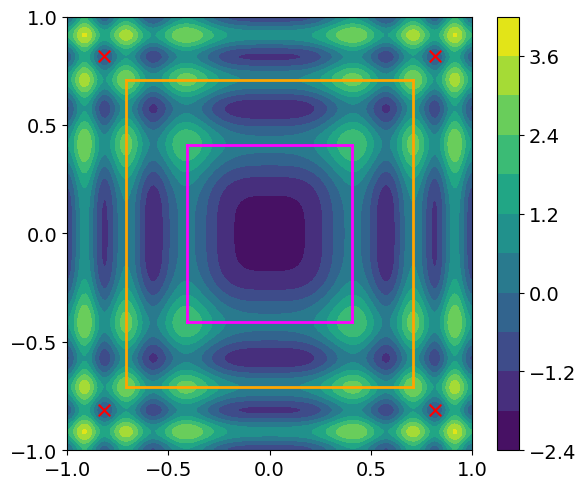

In [62]:
plt.figure(figsize=(6, 5))
plt.contourf(XX, YY, -ZZ, levels=10)
cb = plt.colorbar();
cb.ax.tick_params(labelsize=14)

plt.scatter([0.8156, 0.8156, -0.8156, -0.8156], [0.8156, -0.8156, 0.8156, -0.8156], 
            marker='x', color='red', s=70)

L = 1 / np.sqrt(2)
plt.plot([L, -L], [L, L], color='orange', linewidth=2)
plt.plot([L, L], [L, -L], color='orange', linewidth=2)
plt.plot([L, -L], [-L, -L], color='orange', linewidth=2)
plt.plot([-L, -L], [L, -L], color='orange', linewidth=2);

L = 1 / np.sqrt(6)
plt.plot([L, -L], [L, L], color='magenta', linewidth=2)
plt.plot([L, L], [L, -L], color='magenta', linewidth=2)
plt.plot([L, -L], [-L, -L], color='magenta', linewidth=2)
plt.plot([-L, -L], [L, -L], color='magenta', linewidth=2);

plt.xticks([-1, -0.5, 0, 0.5, 1], fontsize=14)
plt.yticks([-1, -0.5, 0, 0.5, 1], fontsize=14)
plt.tight_layout();
plt.savefig("multimodal_optimization.pdf", pad_inches=0, bbox_inches=0)

In [27]:
root_dir = "optimization_results/"
filenames = os.listdir(root_dir)

In [117]:
NUM_TRIALS = 100
indices = np.arange(40_000)
chain_means = np.zeros((40_000, NUM_TRIALS))
best_val = np.zeros((NUM_TRIALS, 5))
first_escape = np.zeros((NUM_TRIALS, 5))
second_escape = np.zeros((NUM_TRIALS, 5))
chain_variance = np.zeros(40_000)

first_basin = 1 / np.sqrt(2)
second_basin = 1 / np.sqrt(6)

for i in range(NUM_TRIALS):
    chains = np.load(f"optimization_results/InteractingDikinLangevin_chains_5_trial_{i}.npy")
    
    vals = -log_pdf(chains)
    best_val[i, :] = np.min(vals, axis=0)
    
    chain_means[:, i] = vals.mean(axis=-1)
    
    abs_chains = np.abs(chains)
    mask = (abs_chains < first_basin).all(axis=-1)
    first_escape[i, :] = (mask * indices[:, None] + 50_000 * (~mask)).min(axis=0)
    
    mask = (abs_chains < second_basin).all(axis=-1)
    second_escape[i, :] = (mask * indices[:, None] + 50_000 * (~mask)).min(axis=0)
    
    mean = np.mean(chains, axis=1)
    var = np.linalg.norm(chains - mean[:, None, :], axis=-1) ** 2
    chain_variance += var.sum(axis=-1) / NUM_TRIALS

(1, 10)

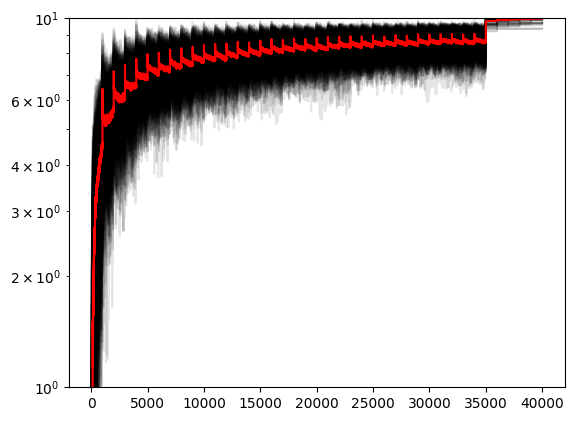

In [128]:
plt.plot(-chain_means, color='black', alpha=0.1);
plt.plot(-chain_means.mean(axis=1), color='red', alpha=1);
plt.yscale('log')
plt.ylim(1, 10)

In [121]:
chain_means_no_resample = np.zeros((40_000, NUM_TRIALS))
best_val_no_resample = np.zeros((NUM_TRIALS, 5))
first_escape_no_resample = np.zeros((NUM_TRIALS, 5))
second_escape_no_resample = np.zeros((NUM_TRIALS, 5))
chain_variance_no_resample = np.zeros(40_000)

for i in range(NUM_TRIALS):
    chains = np.load(f"optimization_results/InteractingDikinLangevin_NoResample_chains_5_trial_{i}.npy")
    
    vals = -log_pdf(chains)
    best_val_no_resample[i, :] = np.min(vals, axis=0)
    
    chain_means_no_resample[:, i] = vals.mean(axis=-1)
    
    abs_chains = np.abs(chains)
    mask = (abs_chains < first_basin).all(axis=-1)
    first_escape_no_resample[i, :] = (mask * indices[:, None] + 50_000 * (~mask)).min(axis=0)
    
    mask = (abs_chains < second_basin).all(axis=-1)
    second_escape_no_resample[i, :] = (mask * indices[:, None] + 50_000 * (~mask)).min(axis=0)
    
    mean = np.mean(chains, axis=1)
    var = np.linalg.norm(chains - mean[:, None, :], axis=-1) ** 2
    chain_variance_no_resample += var.sum(axis=-1) / NUM_TRIALS

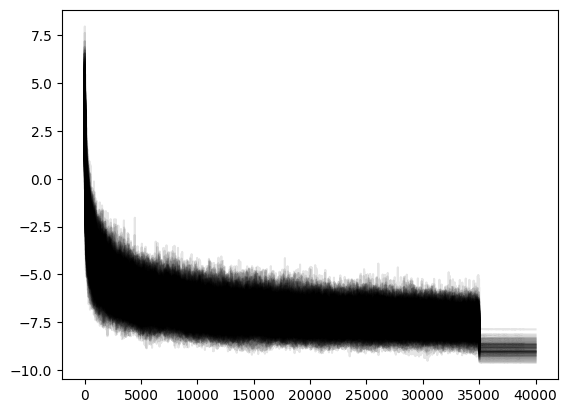

In [122]:
plt.plot(chain_means_no_resample, color='black', alpha=0.1);

In [85]:
df_vals = np.stack([best_val.min(axis=1), first_escape.min(axis=1), second_escape.min(axis=1)]).T
df1 = pd.DataFrame(df_vals, columns=["Vals", "First Escape", "Second Escape"])
df1.describe()

,Vals,First Escape,Second Escape
count,100.000000,100.000000,100.00000
mean,-9.997095,300.490000,2414.53000
std,0.007807,341.792349,2398.51434
min,-10.000000,35.000000,149.00000
25%,-10.000000,112.750000,841.75000
50%,-10.000000,189.000000,1641.00000
75%,-10.000000,322.750000,3146.25000
max,-9.968776,1942.000000,14872.00000


In [86]:
df_vals = np.stack([best_val_no_resample.min(axis=1), 
                    first_escape_no_resample.min(axis=1), 
                    second_escape_no_resample.min(axis=1)]).T
df2 = pd.DataFrame(df_vals, columns=["Vals", "First Escape", "Second Escape"])
df2.describe()

,Vals,First Escape,Second Escape
count,100.000000,100.000000,100.000000
mean,-9.976002,305.170000,2890.650000
std,0.028765,434.243102,2781.340558
min,-10.000000,35.000000,149.000000
25%,-10.000000,112.750000,808.500000
50%,-9.978887,189.000000,1755.000000
75%,-9.966333,322.750000,4395.750000
max,-9.813441,3827.000000,14623.000000


In [104]:
merged = pd.concat({"Interaction": df1.describe(), "No Interaction": df2.describe()}, axis=1)

formatters = [lambda x: f"{x:.2f}", lambda x: f"{int(x):,}", lambda x: f"{int(x):,}"]
formatters += formatters
print(merged.loc[["min", "50%", "max"]].round(2).to_latex(formatters=formatters))

\begin{tabular}{lrrrrrr}
\toprule
 & \multicolumn{3}{r}{Interaction} & \multicolumn{3}{r}{No Interaction} \\
 & Vals & First Escape & Second Escape & Vals & First Escape & Second Escape \\
\midrule
min & -10.00 & 35 & 149 & -10.00 & 35 & 149 \\
50% & -10.00 & 189 & 1,641 & -9.98 & 189 & 1,755 \\
max & -9.97 & 1,942 & 14,872 & -9.81 & 3,827 & 14,623 \\
\bottomrule
\end{tabular}



In [107]:
(df1["Vals"] < -10 + 1e-7).sum()

np.int64(87)

In [108]:
(df2["Vals"] < -10 + 1e-7).sum()

np.int64(36)